# Simple interval approximation (PIA) unfolding (`unfold_interval_pia`)

This notebook applies Rutkowski's PIA — simple interval approximation
— to the IAEA Compendium benchmark spectrum. See:

> S. Rutkowski. Simple interval approximation for solving linear
> algebra problems. Reliable Computing, 1998.

PIA fits a single point spectrum that minimises the distance of the
folded readings to the interval corridors: the per-reading distance
is `e_i(x) = max{(Ax)_i - b_hi_i, b_lo_i - (Ax)_i, 0}`. Minimising
the Chebyshev norm (or weighted L1) of `e` is one LP and yields a
robust estimate for *possibly incompatible* data; for compatible
readings the distance is zero and any corridor-consistent spectrum
obtained.

In [1]:
# %pip install bssunfold pandas numpy matplotlib

## 1. Detector response functions

We use the built-in GSF response functions (10 Bonner spheres, `0in` -
`18in`, 60 energy bins from 1e-9 to ~631 MeV).

Detector grid: 60 bins, 1.0e-09 - 631.0 MeV
Spheres: 0in, 2in, 3in, 5in, 6in, 8in, 10in, 12in, 15in, 18in


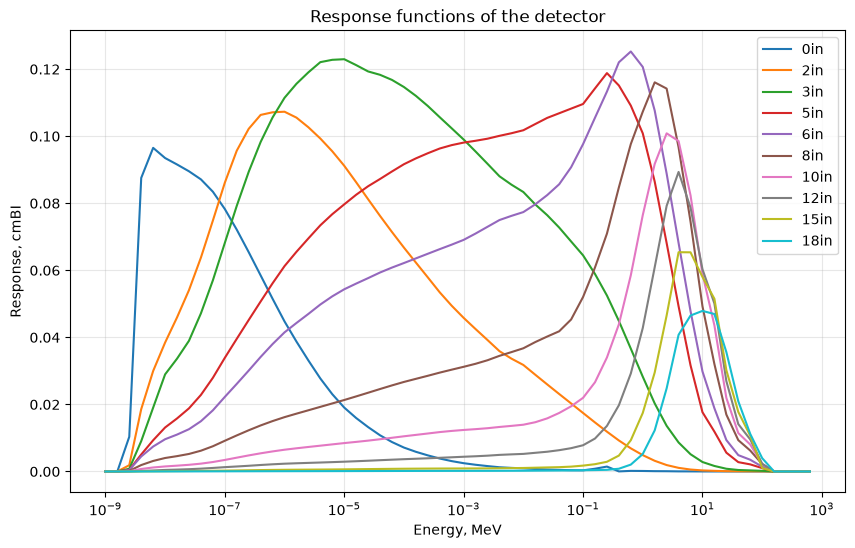

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bssunfold import Detector, RF_GSF
from bssunfold.utils.comparison import compare_spectra

detector = Detector(RF_GSF)
E = detector.E_MeV
names = detector.detector_names
print(f"Detector grid: {detector.n_energy_bins} bins, "
      f"{E[0]:.1e} - {E[-1]:.1f} MeV")
print("Spheres:", ", ".join(names))
detector.plot_response_functions()

## 2. IAEA Compendium reference spectrum -> detector readings

The compendium CSV stores 61-point Monte-Carlo spectra on its own energy
grid, which differs slightly from the 60-bin detector grid, so the
ground truth is interpolated onto the detector grid *for evaluation
only*.  The readings are the spectrum folded with the response
functions.

In [3]:
reference_csv = pd.read_csv(
    '../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv'
)
print(f"Reference CSV: {len(reference_csv)} rows, "
      f"{len(reference_csv.columns) - 1} spectra, "
      f"{reference_csv['E_MeV'].min():.1e} - "
      f"{reference_csv['E_MeV'].max():.0f} MeV")

SPECTRUM = 't4-14-s.txt_1'   # IAEA Compendium BSA benchmark case

readings = detector.get_effective_readings_for_spectra(
    reference_csv[['E_MeV', SPECTRUM]]
)
print("Effective readings:")
for name, val in readings.items():
    print(f"  {name:>4s}: {val:.4f}")

# Interpolate ground truth onto detector grid for evaluation
phi_true = np.interp(
    E, reference_csv['E_MeV'], reference_csv[SPECTRUM]
)

# Active energy bins for plotting
Emax = 20.0
active = E <= Emax
E_active = E[active]
phi_true_active = phi_true[active]

Reference CSV: 61 rows, 20 spectra, 1.0e-09 - 631 MeV
Effective readings:
   0in: 0.0668
   2in: 0.0901
   3in: 0.1382
   5in: 0.1639
   6in: 0.1407
   8in: 0.0805
  10in: 0.0392
  12in: 0.0179
  15in: 0.0064
  18in: 0.0031


## 3. Chebyshev PIA on compatible data

With `noise_level=0.05` the readings are compatible, so the total
distance vanishes and the estimate lies inside all corridors.
Per-reading distances `distances` act as a diagnostic: channels with
non-zero distance are exactly those violated by the fit.

In [4]:
result = detector.unfold_interval_pia(
    readings,
    noise_level=0.05,
    max_neutron_energy=20.0,
    save_result=False,
)
print("method          :", result["method"])
print("norm            :", result["norm"])
print("max distance    :", f"{result['max_distance']:.6f}")
print("total distance  :", f"{result['total_distance']:.6f}")
print("compatible data → distance ~ 0:", result["total_distance"] < 1e-6)
m = compare_spectra(phi_true, result["spectrum"],
                    metrics=["comprehensive_score"])
print(f"score (PIA)     : {m['comprehensive_score']:.3f}")

method          : IntervalPIA
norm            : inf
max distance    : 0.000000
total distance  : 0.000000
compatible data → distance ~ 0: True
score (PIA)     : 2.265


## 4. Robustness: a corrupted reading

The IAEA readings are folded from a spectrum inside the model's own
range, so narrowing the corridors alone never makes them
incompatible. To exercise the robust branch we inflate the `5in`
reading by 20% while keeping 5% corridors. No spectrum then satisfies
all ten corridors — but PIA does not fail: it finds the point
minimising the worst violation (Chebyshev) and reports the per-
reading distances `distances`. This is the natural robust fallback
when classical interval methods return an empty information set.

In [5]:
bad = dict(readings)
bad["5in"] = 1.2 * bad["5in"]

tight = detector.unfold_interval_pia(
    bad,
    noise_level=0.05,
    max_neutron_energy=20.0,
    save_result=False,
)
d = np.asarray(tight["distances"])
worst = np.argsort(-d)
print("Chebyshev distance:", f"{tight['max_distance']:.6f}")
print("violated readings:")
for i in worst[:3]:
    print(f"  {names[i]:>4s}: {d[i]:.6f}")

Chebyshev distance: 0.001517
violated readings:
   0in: 0.001517
   2in: 0.001517
   3in: 0.001517


## 5. Norm comparison: `inf` vs `one`

Chebyshev PIA equalises the violations (minimises the maximum), while
L1 PIA tolerates one large violation to keep the others near zero.
On the corrupted `5in` dataset the difference is instructive: the L1
fit concentrates the whole discrepancy in the corrupted channel
(`total_distance = epsilon` at `5in`, other readings fitted inside
their corridors), whereas Chebyshev distributes small violations over
all channels at the price of a smaller maximum. Both are LPs; the
choice of norm is a modelling decision, and per-channel `weights`
make the L1 variant a weighted robust fit.

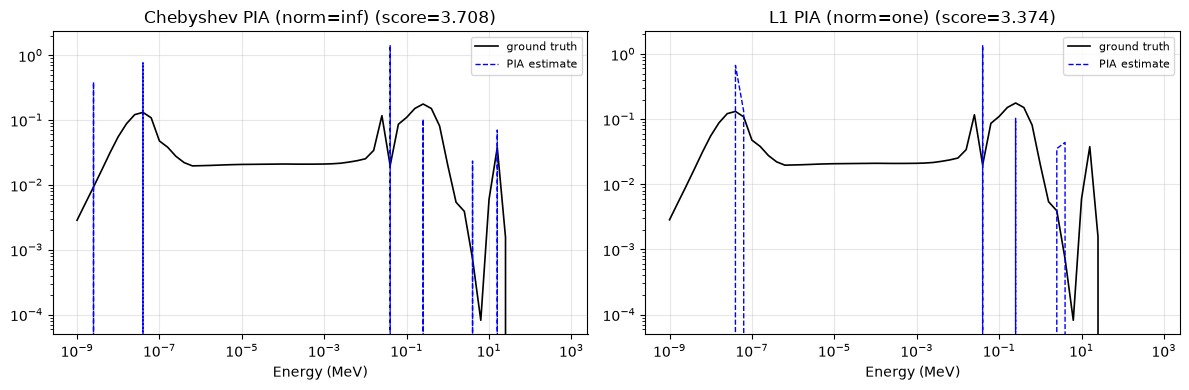

              max d    total d     d(5in) n violated
inf        0.001517   0.015168   0.001517         10
one        0.004517   0.004517   0.004517          1


In [6]:
res_inf = detector.unfold_interval_pia(
    bad, noise_level=0.05, max_neutron_energy=20.0,
    norm="inf", save_result=False,
)
res_one = detector.unfold_interval_pia(
    bad, noise_level=0.05, max_neutron_energy=20.0,
    norm="one", save_result=False,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, res, title in [
    (axes[0], res_inf, "Chebyshev PIA (norm=inf)"),
    (axes[1], res_one, "L1 PIA (norm=one)"),
]:
    ax.loglog(E, phi_true, "k-", lw=1.2, label="ground truth")
    ax.loglog(E, res["spectrum"], "b--", lw=1, label="PIA estimate")
    score = compare_spectra(phi_true, res["spectrum"],
                            metrics=["comprehensive_score"])
    ax.set_title(f"{title} (score={score['comprehensive_score']:.3f})")
    ax.set_xlabel("Energy (MeV)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

d_inf = np.asarray(res_inf["distances"])
d_one = np.asarray(res_one["distances"])
print(f"{'':8s} {'max d':>10s} {'total d':>10s} {'d(5in)':>10s} {'n violated':>10s}")
for label, res, dv in [("inf", res_inf, d_inf), ("one", res_one, d_one)]:
    print(f"{label:<8s} {res['max_distance']:>10.6f} "
          f"{res['total_distance']:>10.6f} "
          f"{dv[names.index('5in')]:>10.6f} "
          f"{int(np.sum(dv > 1e-9)):>10d}")

## 6. Optional guaranteed bounds

PIA itself returns a point estimate. Setting `compute_bounds=True`
additionally runs the componentwise 2n-LP hull over the *repaired*
corridors, so the result dict carries `spectrum_lower`/
`spectrum_upper` like the other interval methods (with mirrored point
estimate when the hull is not requested).

bounds computed : True
total width     : 86.2840


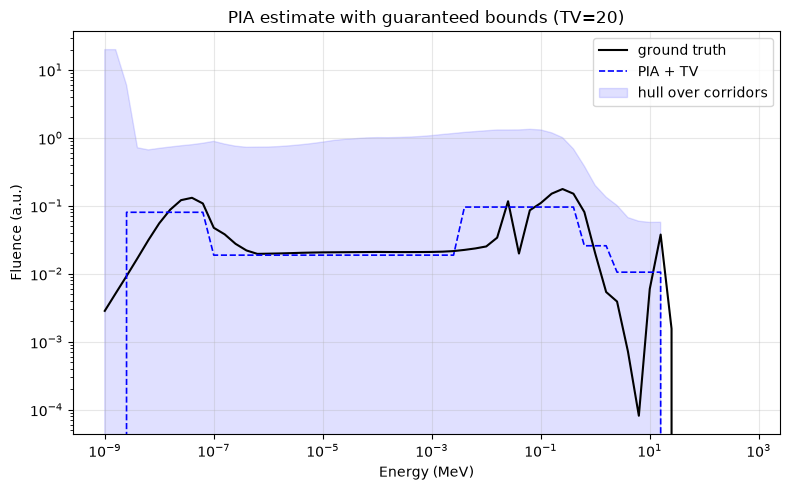

In [7]:
res_bounds = detector.unfold_interval_pia(
    readings,
    noise_level=0.05,
    tv_bound=20.0,
    max_neutron_energy=20.0,
    compute_bounds=True,
    save_result=False,
)
width = np.sum(res_bounds["spectrum_upper"] - res_bounds["spectrum_lower"])
print("bounds computed :", res_bounds["bounds_computed"])
print(f"total width     : {width:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(E, phi_true, "k-", lw=1.5, label="ground truth")
ax.loglog(E, res_bounds["spectrum"], "b--", lw=1.2, label="PIA + TV")
ax.fill_between(E, res_bounds["spectrum_lower"],
                res_bounds["spectrum_upper"], color="blue", alpha=0.12,
                label="hull over corridors")
ax.set_xlabel("Energy (MeV)")
ax.set_ylabel("Fluence (a.u.)")
ax.set_title("PIA estimate with guaranteed bounds (TV=20)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Baselines

In [8]:
grav = detector.unfold_gravel(
    readings,
    initial_spectrum=np.full(E.size, 0.5),
    max_iterations=2000,
    save_result=False,
)
mlem = detector.unfold_mlem(
    readings,
    initial_spectrum=np.full(E.size, 0.5),
    max_iterations=2000,
    save_result=False,
)
print(f"{'method':<24s} {'score':>8s}")
print("-" * 34)
for label, spec in [
    ("PIA", result["spectrum"]),
    ("GRAVEL", grav["spectrum"]),
    ("MLEM", mlem["spectrum"]),
]:
    m = compare_spectra(phi_true, spec, metrics=["comprehensive_score"])
    print(f"{label:<24s} {m['comprehensive_score']:>8.3f}")

method                      score
----------------------------------
PIA                         2.265
GRAVEL                      2.954
MLEM                        1.519


## 8. Summary

* `unfold_interval_pia` minimises the distance to the interval
  corridors — a robust LP estimate for compatible *and* incompatible
  data (Rutkowski's PIA).
* `norm="inf"` (Chebyshev) and `norm="one"` (weighted L1) are both
  exact LPs; `distances` identifies the violated readings.
* Compatible data ⇒ zero distance (principle of agreement);
  `compute_bounds=True` adds the componentwise hull for a full
  interval-style result.